# EDA: Mansueto StopWatch — routes 8, 65, & 66

Phase 1 exploratory analysis before building run-level and stop-level views. Data: `trips_<PID>_full.parquet` on Mansueto CloudFront.

Requires network access to download parquets.

In [1]:
from __future__ import annotations

import urllib.error
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "https://d2v7z51jmtm0iq.cloudfront.net/cta-stop-watch"
RT_TO_PID_URL = f"{BASE}/rt_to_pid.csv"
ROUTES = ["8", "65", "66"]

EXPECTED_COLUMNS = [
    "seg_combined",
    "typ",
    "stop_sequence",
    "bus_stop_time",
    "speed_mph",
    "unique_trip_vehicle_day",
    "stpid",
    "p_stp_id",
    "vid",
    "rt",
    "pid",
]


def parquet_url(pid: str) -> str:
    return f"{BASE}/processed_by_pid/trips_{pid}_full.parquet"


def parquet_http_status(pid: str) -> int:
    url = parquet_url(pid)
    req = urllib.request.Request(url, method="HEAD")
    try:
        with urllib.request.urlopen(req, timeout=120) as resp:
            return resp.status
    except urllib.error.HTTPError as exc:
        return exc.code


def first_available_pid(pids: list[str]) -> str | None:
    for pid in pids:
        if parquet_http_status(pid) == 200:
            return pid
    return None


def load_parquet_columns(pid: str, columns: list[str] | None = None) -> pd.DataFrame | None:
    status = parquet_http_status(pid)
    if status != 200:
        print(f"  SKIP PID {pid}: HTTP {status} (no parquet on CloudFront)")
        return None
    return pd.read_parquet(parquet_url(pid), columns=columns)


## 1. PID discovery

In [2]:
rt_df = pd.read_csv(RT_TO_PID_URL)
rt_df["rt"] = rt_df["rt"].astype(str)
rt_df["pid"] = rt_df["pid"].astype(str)

route_pids = {
    route: rt_df.loc[rt_df["rt"] == route, "pid"].tolist() for route in ROUTES
}

pid_summary = pd.DataFrame(
    [{"route": r, "pid_count": len(pids), "sample_pids": ", ".join(pids[:5])} for r, pids in route_pids.items()]
)
pid_summary

,route,pid_count,sample_pids
0,8,12,"10949, 9368, 10954, 8957, 8388"
1,65,18,"7905, 3213, 7906, 7907, 6652"
2,66,19,"6662, 6665, 4344, 6658, 20426"


Add 56 and 70 as optional additional routes to consider

## 2. Schema consistency check

One PID per route: **first in `rt_to_pid.csv` order with HTTP 200** on CloudFront (any valid file is enough for column names). Compare to verified route 66 / PID 6662 schema.

Sections 4–5 use a **different** sample PID: highest trip count per route from section 3 `volume_df` (see cell after route totals).



In [3]:
schema_rows = []
sample_pid_by_route: dict[str, str] = {}

for route in ROUTES:
    pid = first_available_pid(route_pids[route])
    if pid is None:
        raise SystemExit(f"No available parquet for route {route}")
    sample_pid_by_route[route] = pid
    print(f"Route {route}: loading columns from PID {pid} ...")
    df_cols = load_parquet_columns(pid, columns=None)
    if df_cols is None:
        raise SystemExit(f"Unexpected missing parquet for route {route} PID {pid}")
    cols = list(df_cols.columns)
    schema_rows.append(
        {
            "route": route,
            "pid": pid,
            "n_columns": len(cols),
            "matches_expected": cols == EXPECTED_COLUMNS,
            "columns": ", ".join(cols),
        }
    )
    del df_cols

schema_df = pd.DataFrame(schema_rows)
schema_df[["route", "pid", "n_columns", "matches_expected"]]


Route 8: loading columns from PID 10949 ...
Route 65: loading columns from PID 7905 ...
Route 66: loading columns from PID 6662 ...


,route,pid,n_columns,matches_expected
0,8,10949,11,True
1,65,7905,11,True
2,66,6662,11,True


In [4]:
if not schema_df["matches_expected"].all():
    display(schema_df[~schema_df["matches_expected"]])
else:
    print("All sample PIDs match the 11-column schema verified on route 66 / PID 6662.")

All sample PIDs match the 11-column schema verified on route 66 / PID 6662.


## 3. Data volume and date ranges

Not every PID in `rt_to_pid.csv` has a published `trips_<PID>_full.parquet` (some return HTTP 404).

Per-PID row counts use a minimal column read to reduce memory; missing PIDs are recorded with `http_status` and skipped.


In [5]:
volume_rows = []
for route in ROUTES:
    for pid in route_pids[route]:
        print(f"Route {route} PID {pid} ...")
        status = parquet_http_status(pid)
        if status != 200:
            volume_rows.append(
                {
                    "route": route,
                    "pid": pid,
                    "rows": pd.NA,
                    "trips": pd.NA,
                    "min_time": pd.NaT,
                    "max_time": pd.NaT,
                    "http_status": status,
                    "note": "missing on CloudFront",
                }
            )
            continue
        df = pd.read_parquet(
            parquet_url(pid),
            columns=["bus_stop_time", "unique_trip_vehicle_day"],
        )
        volume_rows.append(
            {
                "route": route,
                "pid": pid,
                "rows": len(df),
                "trips": df["unique_trip_vehicle_day"].nunique(),
                "min_time": df["bus_stop_time"].min(),
                "max_time": df["bus_stop_time"].max(),
                "http_status": 200,
                "note": None,
            }
        )
        del df

volume_df = pd.DataFrame(volume_rows)
volume_df


Route 8 PID 10949 ...
Route 8 PID 9368 ...
Route 8 PID 10954 ...
Route 8 PID 8957 ...
Route 8 PID 8388 ...
Route 8 PID 9376 ...
Route 8 PID 8959 ...
Route 8 PID 9250 ...
Route 8 PID 9343 ...
Route 8 PID 9345 ...
Route 8 PID 10951 ...
Route 8 PID 9344 ...
Route 65 PID 7905 ...
Route 65 PID 3213 ...
Route 65 PID 7906 ...
Route 65 PID 7907 ...
Route 65 PID 6652 ...
Route 65 PID 6656 ...
Route 65 PID 6653 ...
Route 65 PID 6657 ...
Route 65 PID 6655 ...
Route 65 PID 2095 ...
Route 65 PID 24001 ...
Route 65 PID 14125 ...
Route 65 PID 7908 ...
Route 65 PID 3963 ...
Route 65 PID 3258 ...
Route 65 PID 8417 ...
Route 65 PID 7909 ...
Route 65 PID 8181 ...
Route 66 PID 6662 ...
Route 66 PID 6665 ...
Route 66 PID 4344 ...
Route 66 PID 6658 ...
Route 66 PID 20426 ...
Route 66 PID 4355 ...
Route 66 PID 6982 ...
Route 66 PID 25904 ...
Route 66 PID 8182 ...
Route 66 PID 4347 ...
Route 66 PID 6660 ...
Route 66 PID 8466 ...
Route 66 PID 4601 ...
Route 66 PID 4353 ...
Route 66 PID 6661 ...
Route 66 PID 43

,route,pid,rows,trips,min_time,max_time,http_status,note
0,8,10949,450982,7160,2022-06-01 16:12:12.482351000,2026-07-27 18:18:53.583470472,200,NaN
1,8,9368,14886744,139866,2022-05-31 23:25:24.752072000,2026-07-28 00:45:16.063942953,200,NaN
2,8,10954,265164,7140,2022-06-01 07:48:06.057386000,2026-07-27 10:50:39.804322446,200,NaN
3,8,8957,29820,426,2022-07-19 07:11:38.332665000,2025-12-19 08:09:49.219995820,200,NaN
4,8,8388,5904,144,2022-06-04 06:35:52.493869000,2025-03-22 06:59:50.094340583,200,NaN
5,8,9376,13930491,134010,2022-05-31 23:01:22.536015000,2026-07-28 00:38:56.674106422,200,NaN
6,8,8959,216956,2972,2022-06-02 17:54:24.119291000,2026-07-27 19:15:30.934795950,200,NaN
7,8,9250,222205,2837,2022-06-01 07:00:38.768504000,2026-07-27 09:05:52.789995547,200,NaN
8,8,9343,184363,4908,2022-06-01 15:08:14.853919000,2026-07-27 16:26:11.109579274,200,NaN
9,8,9345,498414,7833,2022-06-01 06:36:09.626320000,2026-07-27 09:45:53.592041533,200,NaN


In [6]:
available = volume_df[volume_df["http_status"] == 200].copy()
route_totals = (
    available.groupby("route", as_index=False)
    .agg(rows=("rows", "sum"), trips=("trips", "sum"), min_time=("min_time", "min"), max_time=("max_time", "max"))
)
route_totals


,route,rows,trips,min_time,max_time
0,65,14010166,211759,2022-06-01 04:45:25.955106,2026-07-28 00:10:24.434079710
1,66,31124664,503323,2022-05-31 23:08:07.582262,2026-07-28 01:08:57.086083775
2,8,31110863,313463,2022-05-31 23:01:22.536015,2026-07-28 00:45:16.063942953


In [7]:
# Representative PID for sections 4–5 (dominant pattern by trip count)
for route in ROUTES:
    best = (
        available[available["route"] == route]
        .sort_values("trips", ascending=False)
        .iloc[0]
    )
    sample_pid_by_route[route] = str(best["pid"])
    print(f"Route {route}: sample PID {best['pid']} ({int(best['trips']):,} trips)")



Route 8: sample PID 9368 (139,866 trips)
Route 65: sample PID 6656 (79,716 trips)
Route 66: sample PID 6665 (208,694 trips)


## 4. Stop and trip structure

Uses **highest-trip-count PID** per route from section 3 (updated after route totals). Full parquet read for that PID — can take a minute on large files.



In [8]:
structure = []
trip_by_date_frames = []

for route in ROUTES:
    pid = sample_pid_by_route[route]
    url = parquet_url(pid)
    print(f"Route {route} PID {pid}: loading for structure ...")
    df = pd.read_parquet(url)
    stops_per_trip = df.groupby("unique_trip_vehicle_day")["stpid"].nunique()
    structure.append(
        {
            "route": route,
            "pid": pid,
            "unique_stops": df["stpid"].nunique(),
            "trips": df["unique_trip_vehicle_day"].nunique(),
            "stops_per_trip_median": stops_per_trip.median(),
            "stops_per_trip_min": stops_per_trip.min(),
        }
    )
    daily = df.assign(date=df["bus_stop_time"].dt.date).groupby("date")["unique_trip_vehicle_day"].nunique()
    trip_by_date_frames.append(daily.rename(f"route_{route}"))
    del df

structure_df = pd.DataFrame(structure)
structure_df

Route 8 PID 9368: loading for structure ...
Route 65 PID 6656: loading for structure ...
Route 66 PID 6665: loading for structure ...


,route,pid,unique_stops,trips,stops_per_trip_median,stops_per_trip_min
0,8,9368,113,139866,105.0,9
1,65,6656,77,79716,77.0,76
2,66,6665,79,208694,70.0,7


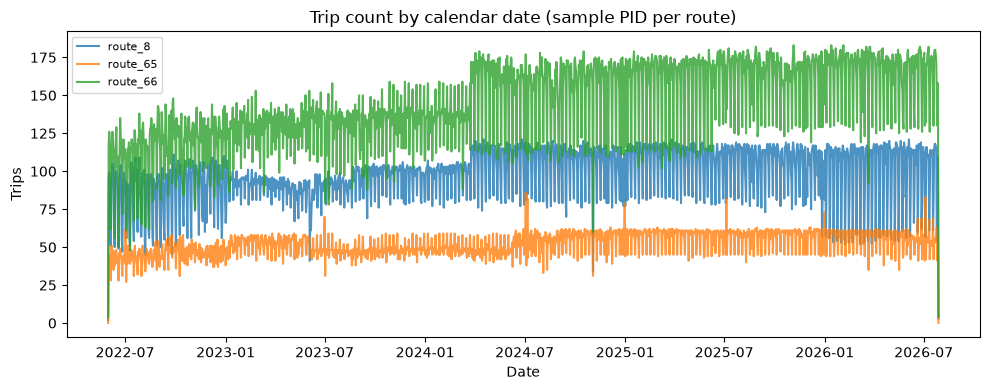

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
trip_by_date = pd.concat(trip_by_date_frames, axis=1).fillna(0).sort_index()
trip_by_date.plot(ax=ax, alpha=0.8)
ax.set_title("Trip count by calendar date (sample PID per route)")
ax.set_xlabel("Date")
ax.set_ylabel("Trips")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Arrival patterns

In [10]:
hour_frames = []
weekday_frames = []

for route in ROUTES:
    pid = sample_pid_by_route[route]
    df = pd.read_parquet(parquet_url(pid), columns=["bus_stop_time", "stpid"])
    hours = df["bus_stop_time"].dt.hour
    hour_frames.append(hours.rename(route))
    dow = df["bus_stop_time"].dt.dayofweek
    weekday_frames.append(
        pd.Series(
            {
                "weekday": int((dow < 5).sum()),
                "weekend": int((dow >= 5).sum()),
            },
            name=route,
        )
    )
    del df

weekday_df = pd.DataFrame(weekday_frames).T
weekday_df

,8,65,66
weekday,11424589,4440612,10643466
weekend,3462155,1658011,3554572


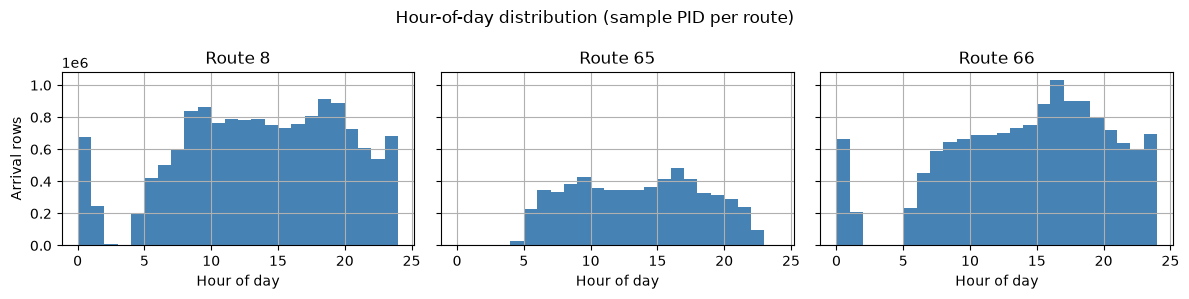

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, route, hours in zip(axes, ROUTES, hour_frames):
    hours.hist(bins=24, range=(0, 24), ax=ax, color="steelblue")
    ax.set_title(f"Route {route}")
    ax.set_xlabel("Hour of day")
axes[0].set_ylabel("Arrival rows")
fig.suptitle("Hour-of-day distribution (sample PID per route)")
plt.tight_layout()
plt.show()

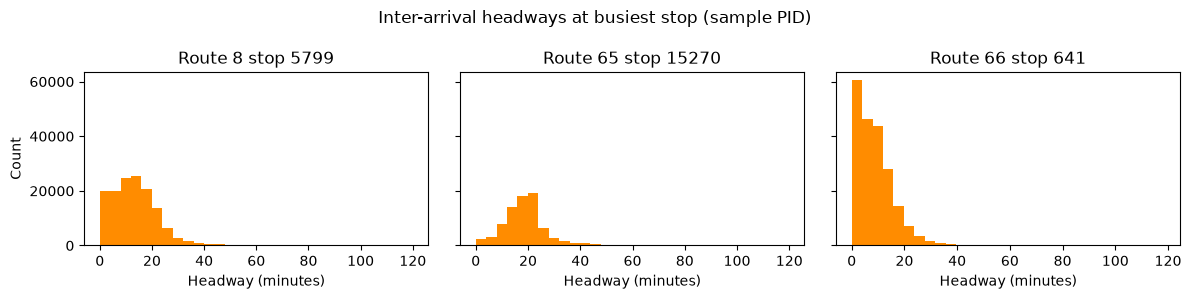

In [12]:
def headways_minutes(times: pd.Series) -> np.ndarray:
    t = pd.to_datetime(times).sort_values()
    if len(t) < 2:
        return np.array([])
    delta = t.diff().dt.total_seconds().iloc[1:] / 60.0
    return delta.to_numpy()


fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, route in zip(axes, ROUTES):
    pid = sample_pid_by_route[route]
    df = pd.read_parquet(parquet_url(pid), columns=["bus_stop_time", "stpid"])
    stop_id = df["stpid"].value_counts().index[0]
    hw = headways_minutes(df.loc[df["stpid"] == stop_id, "bus_stop_time"])
    hw = hw[(hw > 0) & (hw < 120)]
    ax.hist(hw, bins=30, color="darkorange")
    ax.set_title(f"Route {route} stop {stop_id}")
    ax.set_xlabel("Headway (minutes)")
    del df
axes[0].set_ylabel("Count")
fig.suptitle("Inter-arrival headways at busiest stop (sample PID)")
plt.tight_layout()
plt.show()

## 6. Observations and next steps

**Catalog gaps (verified):** Route **65** lists PIDs **7906** and **7907** in `rt_to_pid.csv` but CloudFront returns **404** for those parquets. Ingestion must probe HTTP status (or catch 404) — do not treat the CSV as an authoritative file list.

Fill in after running the notebook:

- **Schema:** Do all routes match the 11-column Mansueto layout? Any extra/missing columns?
- **Volume:** Which routes/PIDs dominate row counts? Date range gaps? How many PIDs 404 per route?
- **Quality:** Partial trips (low stops-per-trip min), sparse dates, or odd hour-of-day spikes?
- **Direction:** Mansueto parquet has no `direction` — ingestion must join GTFS/pattern metadata (`canonical-data-views`).

**Next (see [TODO.md](../TODO.md) Phase 1 Now):**
1. Build run-level view (union **available** PIDs per route, normalize columns, join direction).
2. Build stop-level view for routes 8, 65, & 66.
